In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Day 6 Started")

Day 6 Started


In [5]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'EDA_Analysis.ipynb', 'Performance_Analytics.ipynb', 'Untitled.ipynb']


In [8]:
import os

print(os.listdir("../data"))

['db', 'processed', 'raw']


In [9]:
print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'live_nav_hdfc_top100.csv']


In [10]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [11]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.5 MB


In [12]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [13]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [14]:
var_cvar = nav.groupby("amfi_code")["return"].apply(
    lambda x: pd.Series({
        "VaR_95": np.percentile(x.dropna(), 5),
        "CVaR_95": x[x <= np.percentile(x.dropna(), 5)].mean()
    })
).unstack()

var_cvar.head()

,VaR_95,CVaR_95
amfi_code,,
100016,-0.014364,-0.018060
100025,-0.003793,-0.004994
100033,-0.019034,-0.023456
101206,-0.013282,-0.017439
101207,-0.026021,-0.032459


In [15]:
var_cvar.to_csv("../advanced_analytics/var_cvar_report.csv")

print("Saved Successfully")

Saved Successfully


In [16]:
var_cvar.sort_values("VaR_95").head(10)

,VaR_95,CVaR_95
amfi_code,,
119599,-0.026859,-0.032384
119095,-0.026188,-0.031667
101207,-0.026021,-0.032459
118634,-0.025438,-0.032304
119598,-0.024507,-0.030595
149324,-0.023483,-0.031036
102886,-0.019220,-0.023251
100033,-0.019034,-0.023456
120505,-0.018892,-0.024342


In [17]:
rolling_sharpe = nav.groupby("amfi_code")["return"].transform(
    lambda x: (x.rolling(90).mean() / x.rolling(90).std()) * np.sqrt(252)
)

nav["rolling_sharpe"] = rolling_sharpe

nav.head()

,amfi_code,date,nav,return,rolling_sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN


In [18]:
nav[["amfi_code","date","rolling_sharpe"]].tail()

,amfi_code,date,rolling_sharpe
45995,149324,2026-05-25,2.042795
45996,149324,2026-05-26,2.064950
45997,149324,2026-05-27,1.952646
45998,149324,2026-05-28,1.406239
45999,149324,2026-05-29,1.262776


In [19]:
top5_funds = nav["amfi_code"].drop_duplicates().head(5)

top5_funds

5750     100016
10350    100025
8050     100033
32200    101206
33350    101207
Name: amfi_code, dtype: int64

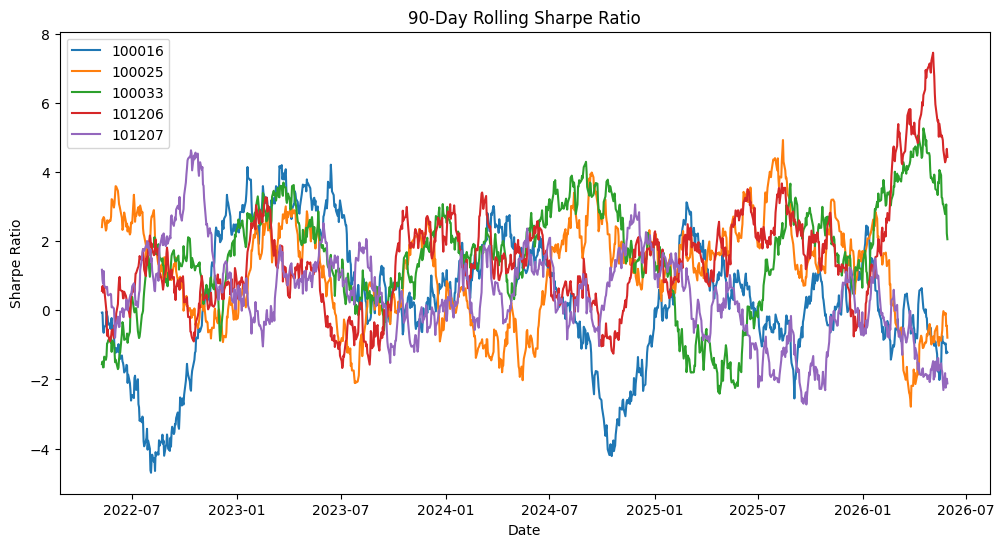

In [20]:
plt.figure(figsize=(12,6))

for fund in top5_funds:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(fund))

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.show()

Chart Saved


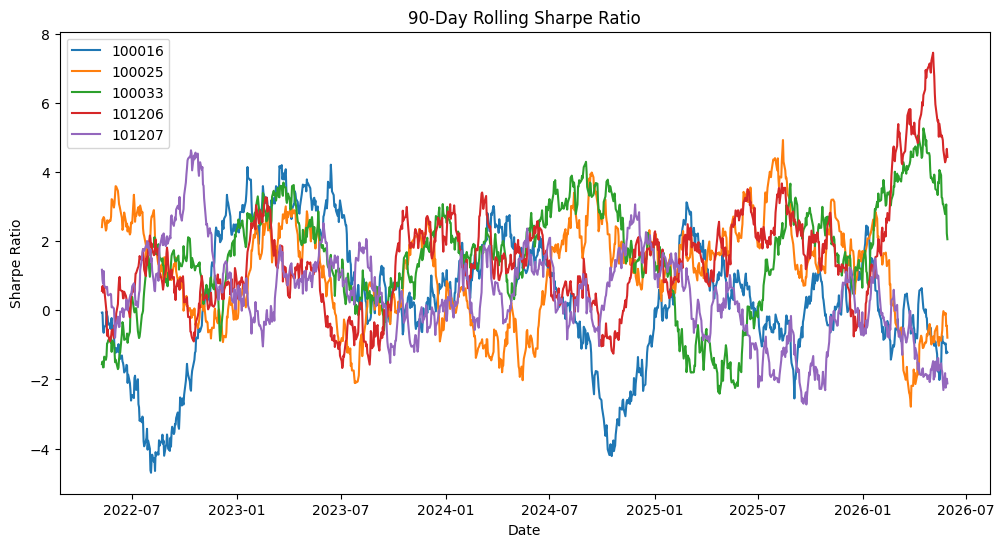

In [21]:
plt.figure(figsize=(12,6))

for fund in top5_funds:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(fund))

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig("../advanced_analytics/rolling_sharpe_chart.png")
print("Chart Saved")

In [22]:
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [23]:
txn.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 5.4 MB


In [24]:
txn.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [25]:
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

In [26]:
first_txn = txn.groupby("investor_id")["transaction_date"].min().reset_index()

first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [27]:
txn = txn.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [28]:
cohort_summary = txn.groupby("cohort_year").agg(
    avg_investment=("amount_inr", "mean"),
    total_investment=("amount_inr", "sum"),
    investors=("investor_id", "nunique")
)

cohort_summary

,avg_investment,total_investment,investors
cohort_year,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [29]:
cohort_summary.to_csv(
    "../advanced_analytics/cohort_analysis.csv"
)

print("Cohort Analysis Saved")

Cohort Analysis Saved


In [30]:
sip_txn = txn[txn["transaction_type"] == "SIP"].copy()

sip_txn["transaction_date"] = pd.to_datetime(
    sip_txn["transaction_date"]
)

sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [31]:
sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")
           ["transaction_date"]
           .diff()
           .dt.days
)

sip_txn.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [32]:
risk_investors = sip_txn.groupby("investor_id")["gap_days"].max()

risk_investors = risk_investors.reset_index()

risk_investors["status"] = np.where(
    risk_investors["gap_days"] > 35,
    "At-Risk",
    "Healthy"
)

risk_investors.head()

,investor_id,gap_days,status
0,INV000001,76.0,At-Risk
1,INV000002,238.0,At-Risk
2,INV000003,238.0,At-Risk
3,INV000004,265.0,At-Risk
4,INV000005,19.0,Healthy


In [33]:
risk_investors["status"].value_counts()

status
At-Risk    3906
Healthy     856
Name: count, dtype: int64

In [34]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [35]:
fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 9.9 KB


In [36]:
def recommend_funds(risk_level):

    if risk_level == "Low":
        rec = fund_master[
            fund_master["risk_category"].str.contains(
                "Low", case=False, na=False
            )
        ]

    elif risk_level == "Moderate":
        rec = fund_master[
            fund_master["risk_category"].str.contains(
                "Moderate", case=False, na=False
            )
        ]

    else:
        rec = fund_master[
            fund_master["risk_category"].str.contains(
                "High", case=False, na=False
            )
        ]

    return rec[
        ["amfi_code","scheme_name","category","risk_category"]
    ].head(3)

In [37]:
recommend_funds("Low")

,amfi_code,scheme_name,category,risk_category
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,Low
14,120507,ICICI Pru Liquid Fund - Regular - Growth,Debt,Low


In [38]:
recommend_funds("Moderate")

,amfi_code,scheme_name,category,risk_category
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Equity,Moderate
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Moderate


In [39]:
recommend_funds("High")

,amfi_code,scheme_name,category,risk_category
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Very High
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High


In [40]:
low = recommend_funds("Low")
moderate = recommend_funds("Moderate")
high = recommend_funds("High")

recommender_output = pd.concat(
    [low, moderate, high]
)

recommender_output.to_csv(
    "../advanced_analytics/recommender_output.csv",
    index=False
)

print("Recommender Saved")

Recommender Saved


In [41]:
import os

print(os.listdir("../advanced_analytics"))

['cohort_analysis.csv', 'recommender_output.csv', 'rolling_sharpe_chart.png', 'var_cvar_report.csv']


In [42]:
%%writefile ../advanced_analytics/recommender.py

import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

def recommend_funds(risk_level):

    if risk_level == "Low":
        rec = fund_master[
            fund_master["risk_category"].str.contains(
                "Low", case=False, na=False
            )
        ]

    elif risk_level == "Moderate":
        rec = fund_master[
            fund_master["risk_category"].str.contains(
                "Moderate", case=False, na=False
            )
        ]

    else:
        rec = fund_master[
            fund_master["risk_category"].str.contains(
                "High", case=False, na=False
            )
        ]

    return rec[
        ["amfi_code","scheme_name","category","risk_category"]
    ].head(3)

print(recommend_funds("High"))

Writing ../advanced_analytics/recommender.py


In [43]:
import os
print(os.listdir("../advanced_analytics"))

['cohort_analysis.csv', 'recommender.py', 'recommender_output.csv', 'rolling_sharpe_chart.png', 'var_cvar_report.csv']


# Advanced Insights

1. Fund 119599 shows the highest downside risk based on Historical VaR analysis.

2. CVaR values indicate that losses beyond the VaR threshold can be significantly larger during stressed market conditions.

3. Several schemes achieved Rolling Sharpe Ratios above 2, indicating strong risk-adjusted performance.

4. Investors who joined in 2024 contribute the majority of total invested capital and investor count.

5. Around 3906 investors are classified as At-Risk due to SIP gaps greater than 35 days.